In [3]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random


In [4]:
def split_image_into_grids(image, N):
    """
    Splits the given image into N x N grids.

    Parameters:
        image (numpy.ndarray): The input image loaded with OpenCV.
        N (int): Number of rows and columns to split the image into.

    Returns:
        grids (list): A list of grid cells (as image crops).
    """
    if image is None:
        raise ValueError("The provided image is None.")
    
    height, width = image.shape[:2]

    grid_h = height // N
    grid_w = width // N

    grids = []

    for i in range(N):
        for j in range(N):
            top = i * grid_h
            left = j * grid_w
            bottom = (i + 1) * grid_h if i < N - 1 else height
            right = (j + 1) * grid_w if j < N - 1 else width

            grid = image[top:bottom, left:right]
            grids.append(grid)

    return grids


../filters-results/imgs/IR_warped.png


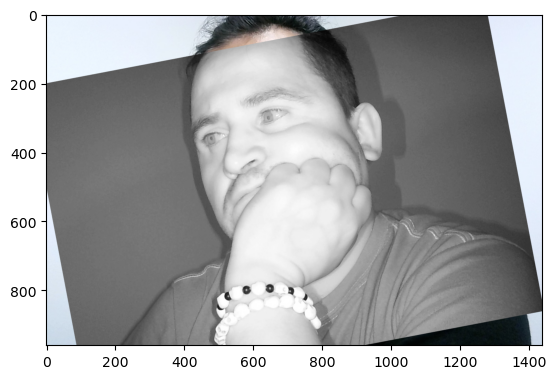

In [9]:
#imgs_folder = "imgs_plants"
imgs_folder  = '../filters-results/imgs'
f = "Photo on 7-1-25 at 5.13 PM.JPG" #IR
#f = "Photo on 7-1-25 at 5.11 PM #2.JPG" #RGB
f = "IR_warped.png"
#f = "shapes.png"
i = os.path.join(imgs_folder,f)
print(i)
img = cv2.imread(i)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [11]:
f = "Photo on 7-1-25 at 5.11 PM #2.JPG"
i = os.path.join(imgs_folder,f)
noir = img = cv2.imread(i)
noir_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

#f = "Photo on 7-1-25 at 5.13 PM.JPG"
f = "IR_warped.png"
i = os.path.join(imgs_folder,f)
ir = img = cv2.imread(i)
ir_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [51]:
SIDE = 7
ir_cells = split_image_into_grids(ir_rgb, SIDE)  
noir_cells = split_image_into_grids(noir_rgb, SIDE)  
combined = []
for i in range(SIDE*SIDE):
    if i % 2:
        combined.append(ir_cells[i])
    else:
        combined.append(noir_cells[i])
sq = [combined[i * SIDE:(i + 1) * SIDE] for i in range(SIDE)]
v = []
for h in sq:
    v.append(np.hstack(h))
    
j = np.vstack(v) 


In [53]:
j_bgr = cv2.cvtColor(j,cv2.COLOR_RGB2BGR)
out_folder  = '../filters-results/boxes'
outf =  f"Boxed_{SIDE}_{f}"
of = os.path.join(out_folder, outf)
cv2.imwrite(of, j_bgr)

True

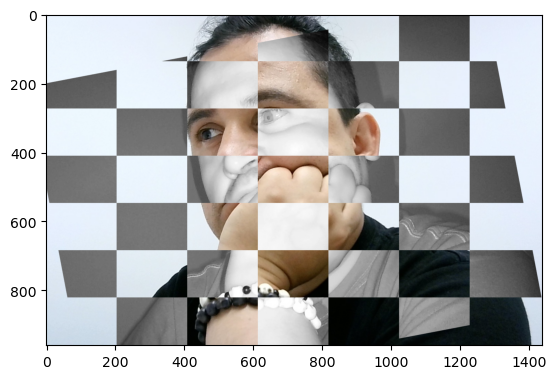

In [55]:
plt.imshow(j)

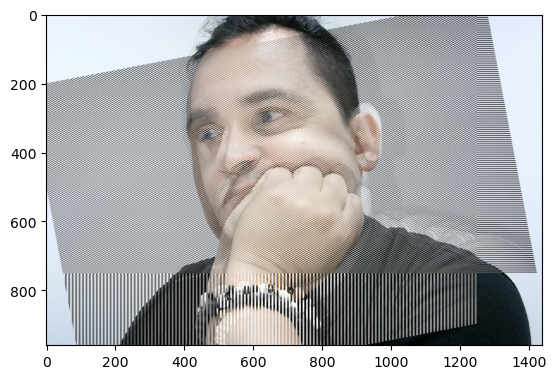

In [364]:
plt.imshow(j)

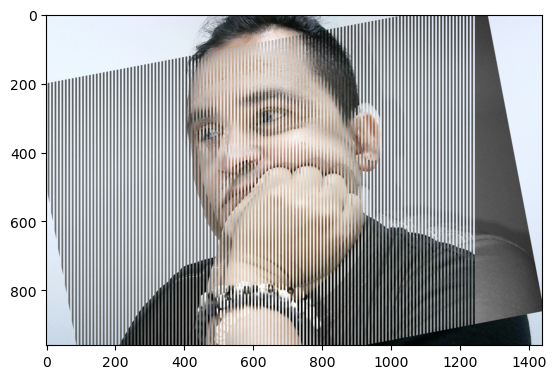

In [360]:
plt.imshow(j)

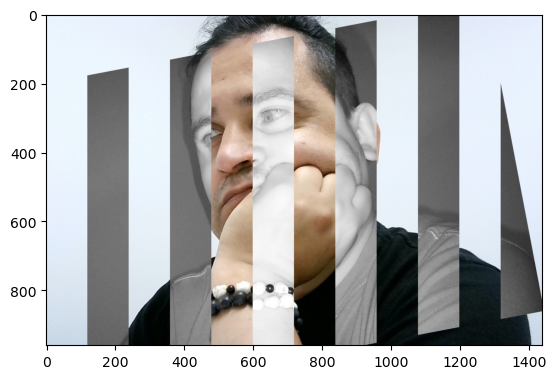

In [348]:
plt.imshow(j)

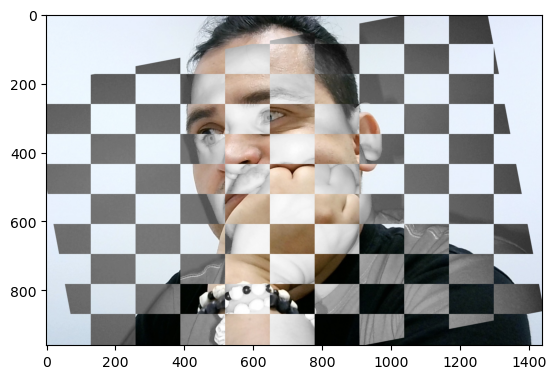

In [338]:
plt.imshow(j)